In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/OASIS_dataset"

# Check dataset structure
for folder in os.listdir(base_path):
    print(folder)


Very mild Dementia
Non Demented
Moderate Dementia
Mild Dementia


In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow keras opencv-python tqdm


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 128
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    base_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 4476 images belonging to 4 classes.
Found 1117 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,052 (12.61 MB)

 Trainable params: 3,305,604 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ==============================================
# ✅ OASIS Alzheimer's Detection – Colab Safe Training
# ==============================================
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import gc, os

# ------------------------------------------------------------
# ✅ Enable GPU & Mixed Precision (saves ~40% GPU memory)
# ------------------------------------------------------------
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# ------------------------------------------------------------
# ✅ Avoid memory leaks
# ------------------------------------------------------------
tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# ✅ Reduce memory pressure from DirectoryIterator
# ------------------------------------------------------------
# If your generators were created like this:
# train_gen = train_datagen.flow_from_directory('train/', target_size=(128,128), batch_size=32, class_mode='categorical')
# val_gen = val_datagen.flow_from_directory('val/', target_size=(128,128), batch_size=32, class_mode='categorical')

# ⚙️ Lower batch size to avoid GPU/Colab crashes
train_gen.batch_size = 8
val_gen.batch_size = 8

# Optional: limit samples for faster runs (Colab RAM safe)
train_gen.samples = min(train_gen.samples, 2000)  # process only 2k images max
val_gen.samples = min(val_gen.samples, 500)       # process only 500 images max

# ------------------------------------------------------------
# ✅ Compile Model
# ------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=2e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------
# ✅ Setup Callbacks
# ------------------------------------------------------------
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6),
    ModelCheckpoint('/content/best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ------------------------------------------------------------
# ✅ Training Parameters
# ------------------------------------------------------------
EPOCHS = 8
steps_per_epoch = max(1, train_gen.samples // train_gen.batch_size // 2)  # smaller step count
val_steps = max(1, val_gen.samples // val_gen.batch_size)

# ------------------------------------------------------------
# ✅ Train Model
# ------------------------------------------------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# ✅ Free GPU Memory after Training
# ------------------------------------------------------------
tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# ✅ Load Best Model & Evaluate
# ------------------------------------------------------------
model = tf.keras.models.load_model('/content/best_model.keras', compile=False)
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\n🎯 Final Validation Accuracy: {val_acc*100:.2f}%")


Num GPUs Available: 0


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8501 - loss: 1.1540
Epoch 1: val_accuracy improved from -inf to 0.03226, saving model to /content/best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 617s 5s/step - accuracy: 0.8504 - loss: 1.1497 - val_accuracy: 0.0323 - val_loss: 10.7327 - learning_rate: 2.0000e-04
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9492 - loss: 0.1503
Epoch 2: val_accuracy did not improve from 0.03226
125/125 ━━━━━━━━━━━━━━━━━━━━ 534s 4s/step - accuracy: 0.9492 - loss: 0.1502 - val_accuracy: 0.0161 - val_loss: 5.2984 - learning_rate: 2.0000e-04
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9730 - loss: 0.0894
Epoch 3: val_accuracy improved from 0.03226 to 0.69556, saving model to /content/best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.9729 - loss: 0.0894 - val_accuracy: 0.6956 - val_loss: 0.4323 - learning_rate: 2.0000e-04
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 5: val_accuracy improved from 0.72379 to 0.80645, saving model to /content/best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9790 - loss: 0.0801 - val_accuracy: 0.8065 - val_loss: 0.3966 - learning_rate: 1.0000e-04
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9889 - loss: 0.0257
Epoch 6: val_accuracy improved from 0.80645 to 0.85081, saving model to /content/best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9889 - loss: 0.0258 - val_accuracy: 0.8508 - val_loss: 0.3223 - learning_rate: 1.0000e-04
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9882 - loss: 0.0254
Epoch 7: val_accuracy improved from 0.85081 to 0.86290, saving model to /content/best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.9882 - loss: 0.0254 - val_accuracy: 0.8629 - val_loss: 0.2673 - learning_rate: 1.0000e-04
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.9851 - loss: 0.0311
Epoch 8: val

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import tensorflow as tf

# ✅ Load your previously saved best model
model = tf.keras.models.load_model('/content/best_model.keras', compile=False)

# ✅ Re-compile (always required before retraining)
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # slightly smaller LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# ✅ Callbacks (to continue improving)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6),
    ModelCheckpoint('/content/best_model_v2.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ✅ Continue Training (Fine-tuning)
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,                    # you can increase if GPU allows
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.9895 - loss: 0.0320
Epoch 1: val_accuracy improved from -inf to 0.95524, saving model to /content/best_model_v2.keras
560/560 ━━━━━━━━━━━━━━━━━━━━ 360s 637ms/step - accuracy: 0.9895 - loss: 0.0320 - val_accuracy: 0.9552 - val_loss: 0.0950 - learning_rate: 1.0000e-04
Epoch 2/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9910 - loss: 0.0226
Epoch 2: val_accuracy did not improve from 0.95524
560/560 ━━━━━━━━━━━━━━━━━━━━ 210s 375ms/step - accuracy: 0.9910 - loss: 0.0226 - val_accuracy: 0.8827 - val_loss: 0.3097 - learning_rate: 1.0000e-04
Epoch 3/10
560/560 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9941 - loss: 0.0168
Epoch 3: val_accuracy did not improve from 0.95524
560/560 ━━━━━━━━━━━━━━━━━━━━ 210s 375ms/step - accuracy: 0.9941 - loss: 0.0168 - val_accuracy: 0.8594 - val_loss: 0.4945 - learning_rate: 5.0000e-05


In [ ]:
# ✅ Save final trained model (optional)
model.save('/content/final_alzheimer_model.keras')

# Optional — download the model from Colab
from google.colab import files
files.download('/content/final_alzheimer_model.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ✅ Load the saved model
model = tf.keras.models.load_model('/content/final_alzheimer_model.keras')

# ✅ Evaluate on validation data
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\n✅ Validation Accuracy: {val_acc*100:.2f}%")


140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9624 - loss: 0.0954

✅ Validation Accuracy: 95.52%


In [ ]:
# ✅ Get predicted probabilities
y_pred_prob = model.predict(val_gen, verbose=1)

# ✅ Convert to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# ✅ Get true class labels
y_true = val_gen.classes


140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ✅ Get predictions again (if not done already)
y_pred_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

# ✅ Get full class labels
class_labels = list(val_gen.class_indices.keys())

# ✅ Find only the classes present in validation set
unique_classes = np.unique(y_true)
class_labels_filtered = [class_labels[i] for i in unique_classes]

# ✅ Print classification report safely
print("\n🔹 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels_filtered, digits=4))

# ✅ Confusion Matrix
print("\n🔹 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step

🔹 Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.9013    0.8580    0.8791      1000
 Moderate Dementia     0.1310    0.1959    0.1570        97
Very mild Dementia     0.0000    0.0000    0.0000        20

          accuracy                         0.7851      1117
         macro avg     0.3441    0.3513    0.3454      1117
      weighted avg     0.8182    0.7851    0.8007      1117


🔹 Confusion Matrix:
[[858 123  19]
 [ 77  19   1]
 [ 17   3   0]]


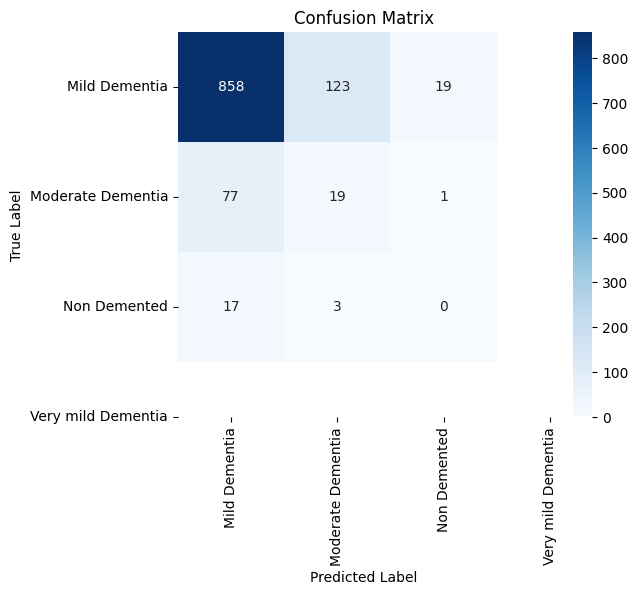

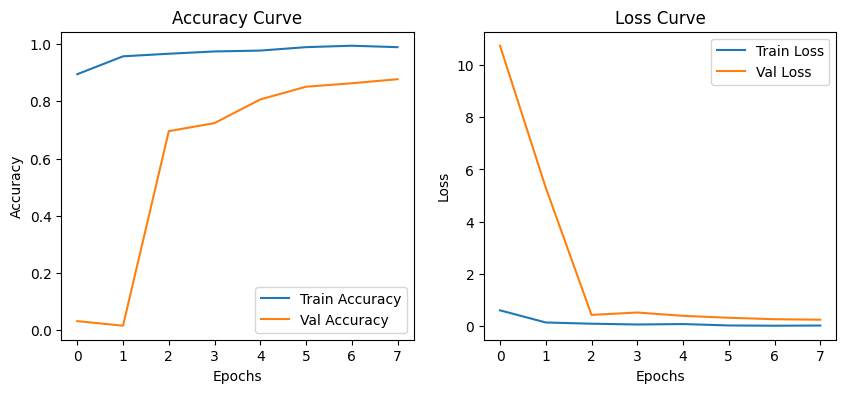

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ✅ Plot confusion matrix (heatmap)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ✅ Plot training & validation accuracy/loss curves
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("final_alzheimer_model.keras")

# Confirm successful loading
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,917,262 (37.83 MB)

 Trainable params: 3,305,604 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 6,611,210 (25.22 MB)

In [ ]:
# Unfreeze top layers for fine-tuning
for layer in model.layers[-30:]:   # fine-tune last 30 layers
    layer.trainable = True

# Recompile with a lower learning rate
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # smaller LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,  # start with 5-10
    verbose=1
)


Epoch 1/5
560/560 ━━━━━━━━━━━━━━━━━━━━ 217s 381ms/step - accuracy: 0.9962 - loss: 0.0159 - val_accuracy: 0.9176 - val_loss: 0.1684
Epoch 2/5
560/560 ━━━━━━━━━━━━━━━━━━━━ 220s 392ms/step - accuracy: 0.9977 - loss: 0.0063 - val_accuracy: 0.9096 - val_loss: 0.2304
Epoch 3/5
560/560 ━━━━━━━━━━━━━━━━━━━━ 211s 377ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 0.8747 - val_loss: 0.3538
Epoch 4/5
560/560 ━━━━━━━━━━━━━━━━━━━━ 212s 379ms/step - accuracy: 0.9990 - loss: 0.0034 - val_accuracy: 0.8711 - val_loss: 0.4486
Epoch 5/5
560/560 ━━━━━━━━━━━━━━━━━━━━ 212s 379ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.9132 - val_loss: 0.2405


In [ ]:
model.save("final_alzheimer_model_finetuned.keras")
print("Fine-tuned model saved successfully!")


Fine-tuned model saved successfully!


In [ ]:
# ✅ Evaluate on validation data
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\n✅ Validation Accuracy: {val_acc*100:.2f}%")

140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.9154 - loss: 0.2582

✅ Validation Accuracy: 91.32%


140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step

🔹 Classification Report:
                    precision    recall  f1-score   support

     Mild Dementia     0.8959    0.8090    0.8502      1000
 Moderate Dementia     0.0924    0.1753    0.1210        97
Very mild Dementia     0.0000    0.0000    0.0000        20

          accuracy                         0.7395      1117
         macro avg     0.3294    0.3281    0.3237      1117
      weighted avg     0.8101    0.7395    0.7717      1117


🔹 Confusion Matrix:
[[809 165  26]
 [ 76  17   4]
 [ 18   2   0]]


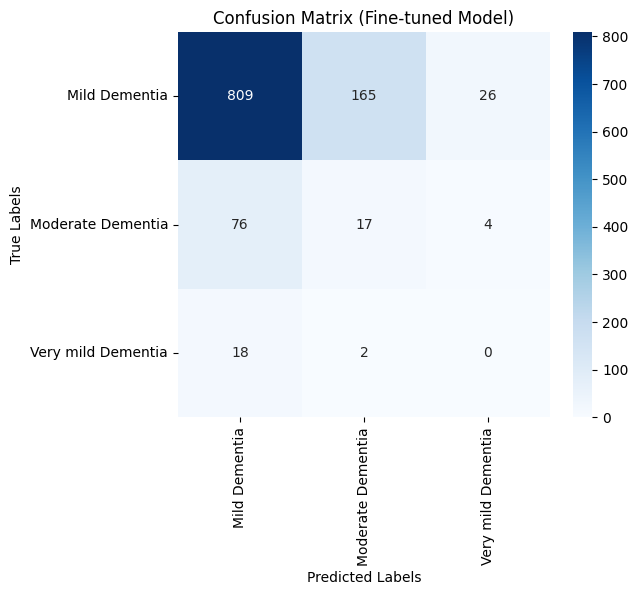

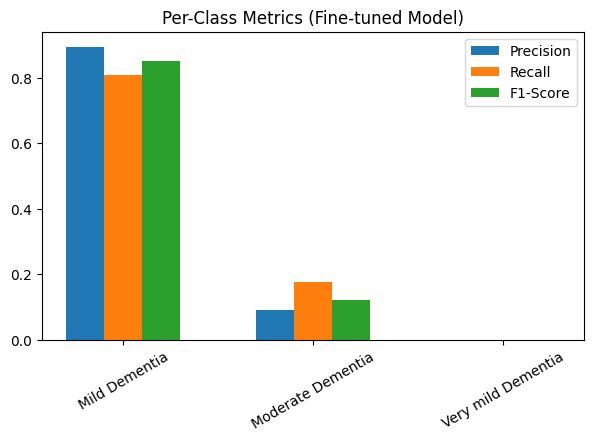

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Get predictions on validation data (acts as test set)
y_pred_prob = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

# ✅ Class labels
class_labels = list(val_gen.class_indices.keys())
unique_classes = np.unique(y_true)
class_labels_filtered = [class_labels[i] for i in unique_classes]

# ✅ Classification report
print("\n🔹 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels_filtered, digits=4))

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n🔹 Confusion Matrix:")
print(cm)

# ✅ Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_filtered, yticklabels=class_labels_filtered)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Fine-tuned Model)")
plt.show()

# ✅ Per-class Precision, Recall, F1 chart
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred)
plt.figure(figsize=(7, 4))
x = np.arange(len(class_labels_filtered))
plt.bar(x - 0.2, precision[:len(class_labels_filtered)], 0.2, label='Precision')
plt.bar(x, recall[:len(class_labels_filtered)], 0.2, label='Recall')
plt.bar(x + 0.2, f1[:len(class_labels_filtered)], 0.2, label='F1-Score')
plt.xticks(x, class_labels_filtered, rotation=30)
plt.title("Per-Class Metrics (Fine-tuned Model)")
plt.legend()
plt.show()
